**Load DA results**

In [53]:
import pickle
import numpy as np
import gurobipy as gp
from gurobipy import GRB

with open("DA_results.pkl", "rb") as f:
    DA = pickle.load(f)

lambda_DA      = DA["lambda_"]
g_DA           = DA["DA_gen_disp"]        # dict {G1: MW, ...}
gen_cap_dict   = DA["DA_gen_cap"]         # list of Pmax
gen_costs      = DA["gen_costs"]          # dict {G1: cost, ...}
VARIABLES      = DA["VARIABLES"]
LOAD_VARIABLES = DA["LOAD_VARIABLES"]
Wind_DA        = np.array(DA["Wind_DA"])
Load_percentage = DA["Load_percentage"]
hour1_load     = DA["hour1_load"]         # make sure you save this in DA notebook too

conv_names = [v for v in VARIABLES if v.startswith('G')]
wind_names = [v for v in VARIABLES if v.startswith('W')]

print(f"λ_DA = {lambda_DA:.2f} $/MWh")
print(f"DA total generation: {sum(g_DA.values()):.2f} MW")

λ_DA = 5.47 $/MWh
DA total generation: 1312.34 MW


**Define BM deviations**

In [54]:
# W1, W2, W3 → 15% less | W4, W5, W6 → 10% more
Wind_actual = Wind_DA.copy()
for idx in [0, 1, 2]:
    Wind_actual[idx] = Wind_DA[idx] * 0.85
for idx in [3, 4, 5]:
    Wind_actual[idx] = Wind_DA[idx] * 1.10

# G8 outage: was scheduled at g_DA['G8'], now produces 0
wind_delta   = np.sum(Wind_actual) - np.sum(Wind_DA)
outage_delta = 0 - g_DA['G8']
total_imbalance = wind_delta + outage_delta   # negative = system short = upward reg needed

print(f"Wind delta:           {wind_delta:+.2f} MW")
print(f"G8 outage delta:      {outage_delta:+.2f} MW")
print(f"Total imbalance:      {total_imbalance:+.2f} MW")
print(f"Direction needed:     {'UPWARD regulation' if total_imbalance < 0 else 'DOWNWARD regulation'}")

Wind delta:           -23.44 MW
G8 outage delta:      +0.00 MW
Total imbalance:      -23.44 MW
Direction needed:     UPWARD regulation


**BM regulation offers**

In [55]:
# Subset = conventional generators with headroom in DA (not at full capacity)
# G8 excluded due to outage

up_reg_offers  = {}   # {Gi: (price, max_MW_up)}
down_reg_offers = {}  # {Gi: (price, max_MW_down)}

for i, g in enumerate(conv_names):
    if g == 'G8':
        continue

    c_i      = gen_costs[g]
    g_da_i   = g_DA[g]
    g_max_i  = gen_cap_dict[i]
    headroom = g_max_i - g_da_i
    footroom = g_da_i

    # Upward reg: DA price + 10% of production cost
    if headroom > 1e-3:
        up_reg_offers[g] = (lambda_DA + 0.10 * c_i, headroom)

    # Downward reg: DA price - 15% of production cost
    if footroom > 1e-3:
        down_reg_offers[g] = (lambda_DA - 0.15 * c_i, footroom)

print("Upward regulation offers:")
for g, (p, mw) in up_reg_offers.items():
    print(f"  {g}: {p:.2f} $/MWh  (max {mw:.2f} MW)")

print("\nDownward regulation offers:")
for g, (p, mw) in down_reg_offers.items():
    print(f"  {g}: {p:.2f} $/MWh  (max {mw:.2f} MW)")

Upward regulation offers:
  G1: 6.80 $/MWh  (max 152.00 MW)
  G2: 6.80 $/MWh  (max 152.00 MW)
  G3: 7.54 $/MWh  (max 350.00 MW)
  G4: 7.56 $/MWh  (max 591.00 MW)
  G5: 8.08 $/MWh  (max 60.00 MW)
  G6: 6.52 $/MWh  (max 155.00 MW)
  G7: 6.52 $/MWh  (max 155.00 MW)
  G9: 6.02 $/MWh  (max 137.41 MW)
  G11: 6.52 $/MWh  (max 310.00 MW)
  G12: 6.56 $/MWh  (max 350.00 MW)

Downward regulation offers:
  G9: 4.65 $/MWh  (max 262.59 MW)
  G10: 5.47 $/MWh  (max 300.00 MW)


**Optimize BM**

In [56]:
model_BM = gp.Model("BM_Hour1")
model_BM.Params.OutputFlag = 1

# Upward regulation variables
r_up = {g: model_BM.addVar(lb=0, ub=mw, name=f'rup_{g}')
        for g, (p, mw) in up_reg_offers.items()}

# Downward regulation variables
r_dn = {g: model_BM.addVar(lb=0, ub=mw, name=f'rdn_{g}')
        for g, (p, mw) in down_reg_offers.items()}

# Load curtailment (last resort, €500/MWh)
curtailment = model_BM.addVar(lb=0, name='curtailment')

# Balance: upward - downward + curtailment = deficit to cover
model_BM.addLConstr(
    gp.quicksum(r_up[g] for g in r_up)
    - gp.quicksum(r_dn[g] for g in r_dn)
    + curtailment,
    GRB.EQUAL,
    -total_imbalance,
    name="BM_balance"
)

# Objective: minimize cost of balancing
obj = (gp.quicksum(up_reg_offers[g][0]   * r_up[g] for g in r_up)
     - gp.quicksum(down_reg_offers[g][0] * r_dn[g] for g in r_dn)
     + 500 * curtailment)

model_BM.setObjective(obj, GRB.MINIMIZE)
model_BM.optimize()

# BM clearing price = dual of balance constraint
lambda_BM = model_BM.getConstrByName("BM_balance").Pi

print(f"\n{'='*50}")
print(f"BM clearing price: λ_BM = {lambda_BM:.2f} $/MWh")
print(f"Curtailment:       {curtailment.X:.2f} MW")
print(f"\nActivated upward regulation:")
for g in r_up:
    if r_up[g].X > 1e-3:
        print(f"  {g}: +{r_up[g].X:.2f} MW at {up_reg_offers[g][0]:.2f} $/MWh")
print(f"Activated downward regulation:")
for g in r_dn:
    if r_dn[g].X > 1e-3:
        print(f"  {g}: -{r_dn[g].X:.2f} MW at {down_reg_offers[g][0]:.2f} $/MWh")

Set parameter OutputFlag to value 1
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 12th Gen Intel(R) Core(TM) i7-1255U, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 1 rows, 13 columns and 13 nonzeros
Model fingerprint: 0xcff756a1
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [5e+00, 5e+02]
  Bounds range     [6e+01, 6e+02]
  RHS range        [2e+01, 2e+01]
Presolve removed 0 rows and 9 columns
Presolve time: 0.01s
Presolved: 1 rows, 4 columns, 4 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0   -2.8618962e+03   7.325384e+01   0.000000e+00      0s
       1    1.4106347e+02   0.000000e+00   0.000000e+00      0s

Solved in 1 iterations and 0.02 seconds (0.00 work units)
Optimal objective  1.410634666e+02

BM clearing price: λ_BM = 6.02 $/MWh
Curtailment:       0.00 MW

Activated upward reg

**Profit under 1-price and 2-price settlement**

In [57]:
print("=" * 60)
print("PROFIT ANALYSIS — DA + BM combined")
print("=" * 60)

for scheme in ["one-price", "two-price"]:
    print(f"\n--- {scheme.upper()} SCHEME ---")
    
    for g in conv_names:
        if g == 'G8':
            da_profit = (lambda_DA - gen_costs[g]) * g_DA[g]
            bm_profit = 0
            print(f"  {g} (OUTAGE): DA profit = {da_profit:.2f} $,  BM = 0,  Total = {da_profit:.2f} $")
            continue
        
        da_profit = (lambda_DA - gen_costs[g]) * g_DA[g]
        
        r_up_i = r_up[g].X  if g in r_up  else 0
        r_dn_i = r_dn[g].X  if g in r_dn  else 0
        
        if scheme == "one-price":
            # All imbalances settled at λ_BM regardless of direction
            bm_profit = lambda_BM * r_up_i - gen_costs[g] * r_up_i \
                      - lambda_BM * r_dn_i + gen_costs[g] * r_dn_i
        else:
            # Two-price: only penalises those who caused imbalance
            # Upward providers get λ_BM, downward providers get λ_DA (no reward for adding to surplus)
            if total_imbalance < 0:   # system short → upward needed
                bm_profit = (lambda_BM - gen_costs[g]) * r_up_i \
                          + (lambda_DA  - gen_costs[g]) * (-r_dn_i)
            else:                      # system long → downward needed
                bm_profit = (lambda_DA  - gen_costs[g]) * r_up_i \
                          + (lambda_BM  - gen_costs[g]) * (-r_dn_i)
        
        total = da_profit + bm_profit
        print(f"  {g}: DA = {da_profit:.2f} $,  BM = {bm_profit:.2f} $,  Total = {total:.2f} $")
    
    print(f"\n  Wind farms (BM settled at λ_BM for actual output):")
    for wi, wname in enumerate(wind_names):
        da_profit_w = (lambda_DA - 0) * list(g_DA.values())[list(VARIABLES).index(wname)]
        delta_w     = Wind_actual[wi] - Wind_DA[wi]
        
        if scheme == "one-price":
            bm_profit_w = lambda_BM * delta_w   # paid/penalised at BM price
        else:
            # Two-price: wind that causes imbalance gets penalised at worse price
            if total_imbalance < 0:   # system short
                bm_profit_w = lambda_BM * max(delta_w, 0) + lambda_DA * min(delta_w, 0)
            else:
                bm_profit_w = lambda_DA * max(delta_w, 0) + lambda_BM * min(delta_w, 0)
        
        total_w = da_profit_w + bm_profit_w
        print(f"  {wname}: DA = {da_profit_w:.2f} $,  BM = {bm_profit_w:.2f} $,  "
              f"Total = {total_w:.2f} $  (deviation: {delta_w:+.2f} MW)")

PROFIT ANALYSIS — DA + BM combined

--- ONE-PRICE SCHEME ---
  G1: DA = -0.00 $,  BM = 0.00 $,  Total = 0.00 $
  G2: DA = -0.00 $,  BM = 0.00 $,  Total = 0.00 $
  G3: DA = -0.00 $,  BM = 0.00 $,  Total = 0.00 $
  G4: DA = -0.00 $,  BM = 0.00 $,  Total = 0.00 $
  G5: DA = -0.00 $,  BM = 0.00 $,  Total = 0.00 $
  G6: DA = -0.00 $,  BM = 0.00 $,  Total = 0.00 $
  G7: DA = -0.00 $,  BM = 0.00 $,  Total = 0.00 $
  G8 (OUTAGE): DA profit = -0.00 $,  BM = 0,  Total = -0.00 $
  G9: DA = 0.00 $,  BM = 12.82 $,  Total = 12.82 $
  G10: DA = 1641.00 $,  BM = 0.00 $,  Total = 1641.00 $
  G11: DA = -0.00 $,  BM = 0.00 $,  Total = 0.00 $
  G12: DA = -0.00 $,  BM = 0.00 $,  Total = 0.00 $

  Wind farms (BM settled at λ_BM for actual output):
  W1: DA = 648.42 $,  BM = -106.99 $,  Total = 541.43 $  (deviation: -17.78 MW)
  W2: DA = 763.80 $,  BM = -126.03 $,  Total = 637.78 $  (deviation: -20.95 MW)
  W3: DA = 741.20 $,  BM = -122.30 $,  Total = 618.90 $  (deviation: -20.33 MW)
  W4: DA = 562.23 $,  BM

In [58]:
print(f"λ_DA (hour 1):      {lambda_DA:.2f} $/MWh")
print(f"Total DA dispatch:  {sum(g_DA.values()):.2f} MW")
print(f"\nDA dispatch per generator:")
for g, mw in g_DA.items():
    cost = gen_costs[g]
    print(f"  {g}: {mw:.2f} MW  (cost: {cost:.2f} $/MWh)  "
          f"{'← dispatched' if mw > 0.01 else '← rejected'}")

λ_DA (hour 1):      5.47 $/MWh
Total DA dispatch:  1312.34 MW

DA dispatch per generator:
  G1: 0.00 MW  (cost: 13.32 $/MWh)  ← rejected
  G2: 0.00 MW  (cost: 13.32 $/MWh)  ← rejected
  G3: 0.00 MW  (cost: 20.70 $/MWh)  ← rejected
  G4: 0.00 MW  (cost: 20.93 $/MWh)  ← rejected
  G5: 0.00 MW  (cost: 26.11 $/MWh)  ← rejected
  G6: 0.00 MW  (cost: 10.52 $/MWh)  ← rejected
  G7: 0.00 MW  (cost: 10.52 $/MWh)  ← rejected
  G8: 0.00 MW  (cost: 6.02 $/MWh)  ← rejected
  G9: 262.59 MW  (cost: 5.47 $/MWh)  ← dispatched
  G10: 300.00 MW  (cost: 0.00 $/MWh)  ← dispatched
  G11: 0.00 MW  (cost: 10.52 $/MWh)  ← rejected
  G12: 0.00 MW  (cost: 10.89 $/MWh)  ← rejected
  W1: 118.54 MW  (cost: 0.00 $/MWh)  ← dispatched
  W2: 139.64 MW  (cost: 0.00 $/MWh)  ← dispatched
  W3: 135.50 MW  (cost: 0.00 $/MWh)  ← dispatched
  W4: 102.78 MW  (cost: 0.00 $/MWh)  ← dispatched
  W5: 131.60 MW  (cost: 0.00 $/MWh)  ← dispatched
  W6: 121.69 MW  (cost: 0.00 $/MWh)  ← dispatched


**PLOTS**

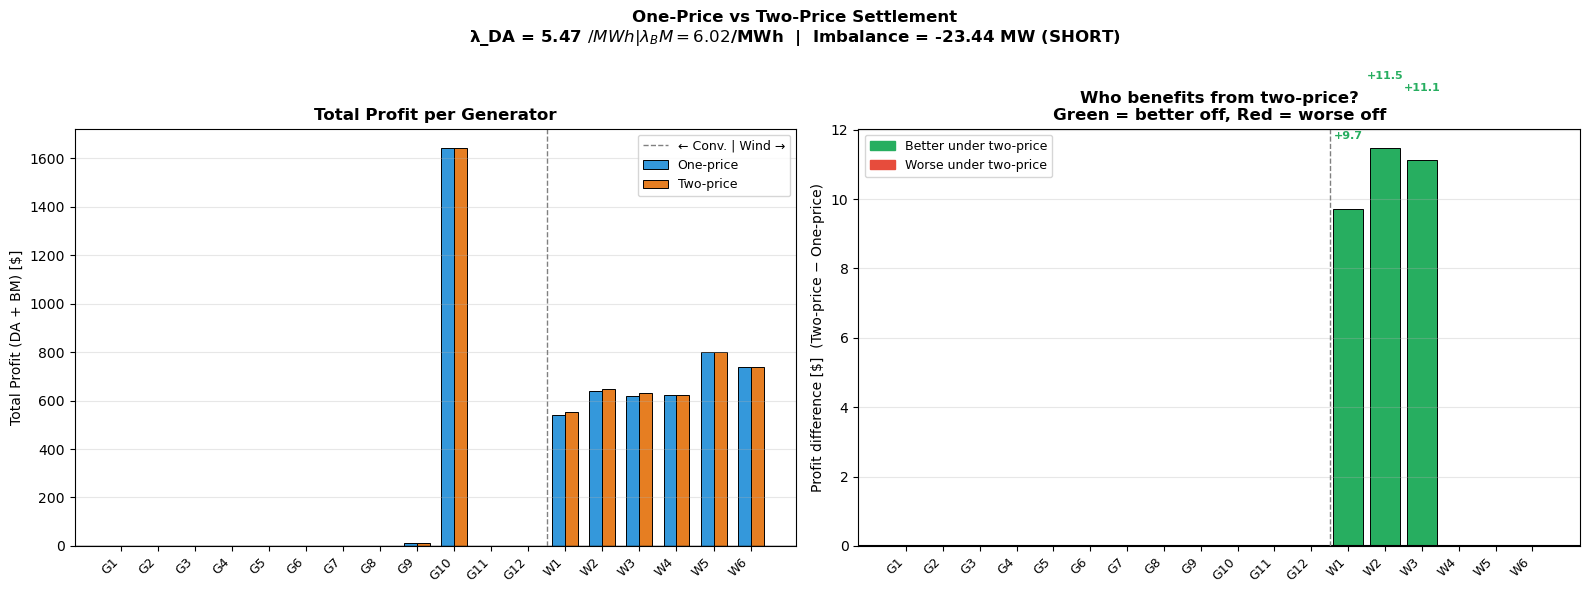

Saved: one_vs_two_price.png


In [59]:
import matplotlib.pyplot as plt
import numpy as np

# ── Collect profits for both schemes ────────────────────────
all_names, one_price_total, two_price_total = [], [], []

for g in conv_names:
    c_i       = gen_costs[g]
    g_da_i    = g_DA[g]
    da_profit = (lambda_DA - c_i) * g_da_i

    r_up_i = r_up[g].X if g in r_up else 0
    r_dn_i = r_dn[g].X if g in r_dn else 0

    if g == 'G8':
        one_p = da_profit
        two_p = da_profit
    else:
        bm_one = (lambda_BM - c_i) * r_up_i - (lambda_BM - c_i) * r_dn_i
        if total_imbalance < 0:
            bm_two = (lambda_BM - c_i) * r_up_i + (lambda_DA - c_i) * (-r_dn_i)
        else:
            bm_two = (lambda_DA - c_i) * r_up_i + (lambda_BM - c_i) * (-r_dn_i)
        one_p = da_profit + bm_one
        two_p = da_profit + bm_two

    all_names.append(g)
    one_price_total.append(one_p)
    two_price_total.append(two_p)

for wi, wname in enumerate(wind_names):
    delta_w     = Wind_actual[wi] - Wind_DA[wi]
    da_profit_w = lambda_DA * g_DA[wname]

    bm_one = lambda_BM * delta_w
    if total_imbalance < 0:
        bm_two = lambda_BM * max(delta_w, 0) + lambda_DA * min(delta_w, 0)
    else:
        bm_two = lambda_DA * max(delta_w, 0) + lambda_BM * min(delta_w, 0)

    all_names.append(wname)
    one_price_total.append(da_profit_w + bm_one)
    two_price_total.append(da_profit_w + bm_two)

one_price_total = np.array(one_price_total)
two_price_total = np.array(two_price_total)
diff            = two_price_total - one_price_total  # + means two-price is better

# ── Figure 1: Total profit comparison ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f"One-Price vs Two-Price Settlement\n"
             f"λ_DA = {lambda_DA:.2f} $/MWh  |  λ_BM = {lambda_BM:.2f} $/MWh  |  "
             f"Imbalance = {total_imbalance:+.2f} MW "
             f"({'SHORT' if total_imbalance < 0 else 'LONG'})",
             fontsize=12, fontweight='bold')

x     = np.arange(len(all_names))
width = 0.35

# ── Left plot: side-by-side total profits ───────────────────
ax = axes[0]
ax.bar(x - width/2, one_price_total, width, color='#3498db',
       edgecolor='black', linewidth=0.7, label='One-price')
ax.bar(x + width/2, two_price_total, width, color='#e67e22',
       edgecolor='black', linewidth=0.7, label='Two-price')

ax.axhline(0, color='black', linewidth=1)
ax.axvline(len(conv_names) - 0.5, color='grey', linestyle='--',
           linewidth=1, label='← Conv. | Wind →')

ax.set_xticks(x)
ax.set_xticklabels(all_names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel("Total Profit (DA + BM) [$]")
ax.set_title("Total Profit per Generator", fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# ── Right plot: difference (two-price minus one-price) ──────
ax = axes[1]
colors = ['#27ae60' if d >= 0 else '#e74c3c' for d in diff]
ax.bar(x, diff, color=colors, edgecolor='black', linewidth=0.7)

ax.axhline(0, color='black', linewidth=1.5)
ax.axvline(len(conv_names) - 0.5, color='grey', linestyle='--', linewidth=1)

# Annotate each bar
for xi, d in enumerate(diff):
    if abs(d) > 0.01:
        ax.text(xi, d + (2 if d >= 0 else -2), f'{d:+.1f}',
                ha='center', fontsize=8, fontweight='bold',
                color='#27ae60' if d >= 0 else '#e74c3c')

ax.set_xticks(x)
ax.set_xticklabels(all_names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel("Profit difference [$]  (Two-price − One-price)")
ax.set_title("Who benefits from two-price?\n"
             "Green = better off, Red = worse off", fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Legend explanation
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#27ae60', label='Better under two-price'),
    Patch(color='#e74c3c', label='Worse under two-price'),
], fontsize=9)

plt.tight_layout()
plt.savefig("one_vs_two_price.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: one_vs_two_price.png")